In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

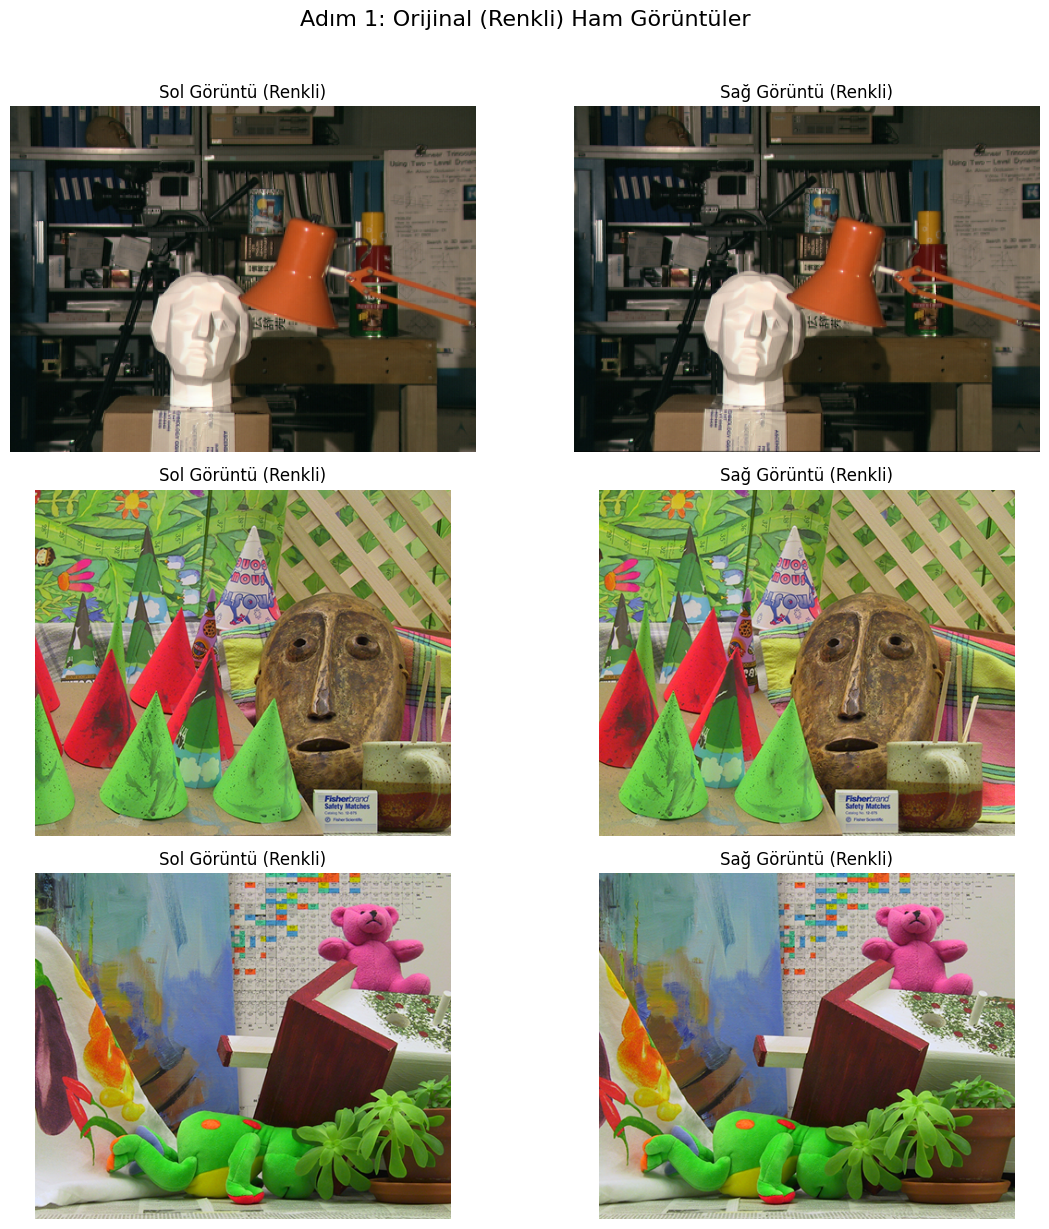

In [2]:
import cv2
import matplotlib.pyplot as plt

gorsel_ciftleri = [
    ('sol1.jpg', 'sag1.jpg'),
    ('sol2.png', 'sag2.png'),
    ('sol3.png', 'sag3.png')
]

fig, eksenler = plt.subplots(nrows=len(gorsel_ciftleri), ncols=2, figsize=(12, 4 * len(gorsel_ciftleri)))
fig.suptitle('Adım 1: Orijinal (Renkli) Ham Görüntüler', fontsize=16, y=1.02)

for i, (sol_dosya, sag_dosya) in enumerate(gorsel_ciftleri):
  
    sol_img_bgr = cv2.imread(sol_dosya)
    sag_img_bgr = cv2.imread(sag_dosya)
    
    if sol_img_bgr is None or sag_img_bgr is None:
        print(f"Hata: {sol_dosya} veya {sag_dosya} okunamadı! Dosya isimlerini kontrol et.")
        continue
        
    sol_img_rgb = cv2.cvtColor(sol_img_bgr, cv2.COLOR_BGR2RGB)
    sag_img_rgb = cv2.cvtColor(sag_img_bgr, cv2.COLOR_BGR2RGB)
    
    # Sol Görüntüleri Ekle
    eksenler[i, 0].imshow(sol_img_rgb)
    eksenler[i, 0].set_title(f"Sol Görüntü (Renkli)")
    eksenler[i, 0].axis('off')
    
    # Sağ Görüntüleri Ekle
    eksenler[i, 1].imshow(sag_img_rgb)
    eksenler[i, 1].set_title(f"Sağ Görüntü (Renkli)")
    eksenler[i, 1].axis('off')

plt.tight_layout()
plt.show()

Görüntüleri Alma ve Gri Tonlamaya Çevirme
Stereo eşleştirme algoritmaları genellikle renkli (RGB) pikseller yerine gri tonlamalı (tek kanallı) piksellerin yoğunlukları üzerinden çalışır. Bu yüzden kameradan aldığımız görüntüleri siyah-beyaza çevirmeliyiz.

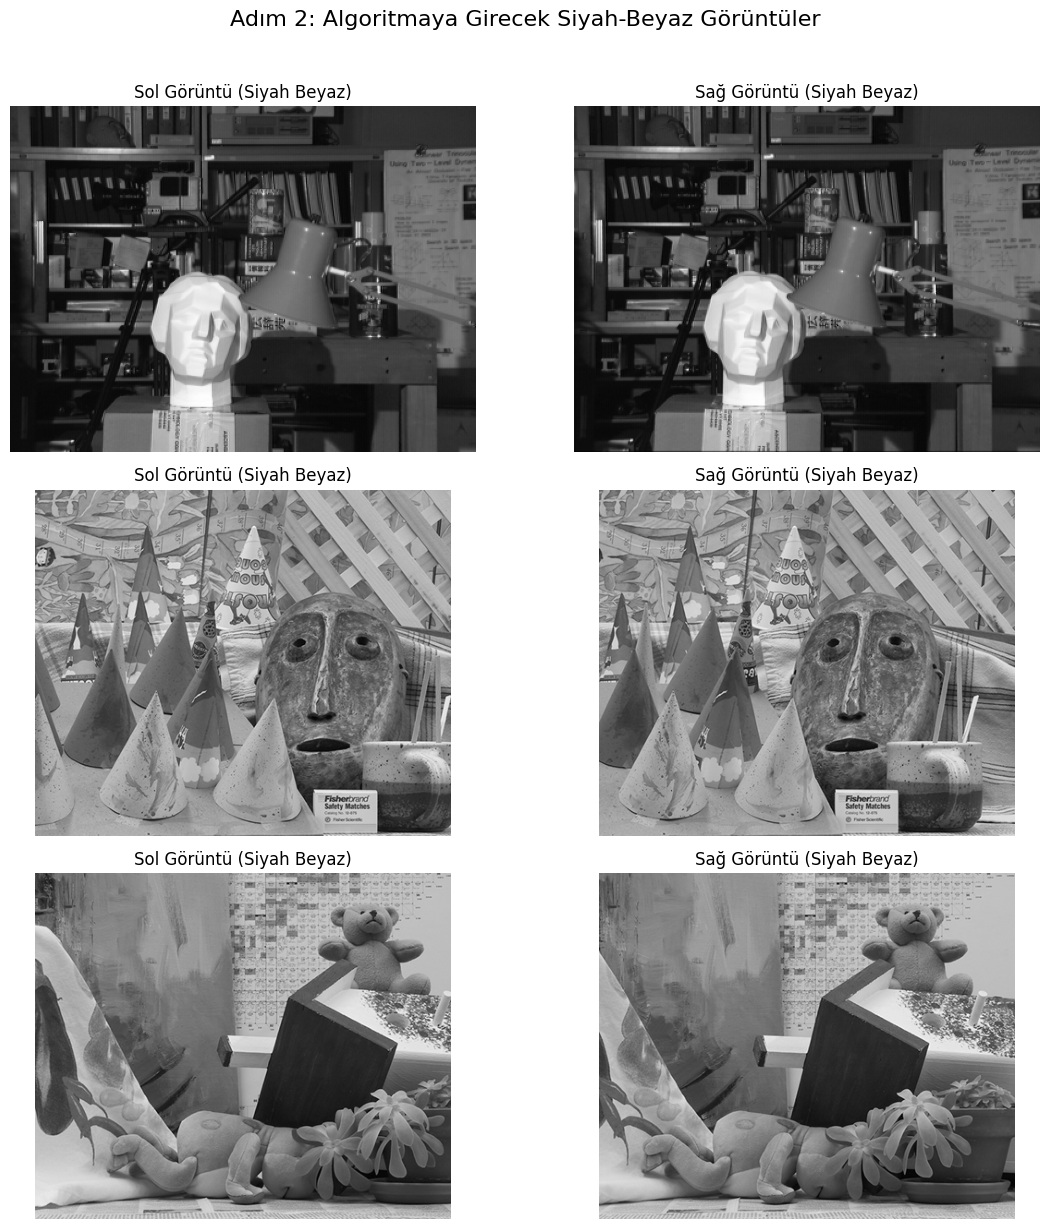

In [3]:
fig, eksenler = plt.subplots(nrows=len(gorsel_ciftleri), ncols=2, figsize=(12, 4 * len(gorsel_ciftleri)))
fig.suptitle('Adım 2: Algoritmaya Girecek Siyah-Beyaz Görüntüler', fontsize=16, y=1.02)

for i, (sol_dosya, sag_dosya) in enumerate(gorsel_ciftleri):
  
    sol_img_gray = cv2.imread(sol_dosya, 0)
    sag_img_gray = cv2.imread(sag_dosya, 0)
    
    if sol_img_gray is None or sag_img_gray is None:
        continue
    #Sol Görüntüleri Ekle
    eksenler[i, 0].imshow(sol_img_gray, cmap='gray')
    eksenler[i, 0].set_title(f"Sol Görüntü (Siyah Beyaz)")
    eksenler[i, 0].axis('off')
    
    # Sağ Görüntüleri Ekle
    eksenler[i, 1].imshow(sag_img_gray, cmap='gray')
    eksenler[i, 1].set_title(f"Sağ Görüntü (Siyah Beyaz)")
    eksenler[i, 1].axis('off')

plt.tight_layout()
plt.show()


--- 1. Görsel çifti işleniyor ---
İlerleme: Satır 40/240 işleniyor...
İlerleme: Satır 80/240 işleniyor...
İlerleme: Satır 120/240 işleniyor...
İlerleme: Satır 160/240 işleniyor...
İlerleme: Satır 200/240 işleniyor...
Hesaplama tamamlandı! Süre: 15.57 saniye.

--- 2. Görsel çifti işleniyor ---
İlerleme: Satır 40/240 işleniyor...
İlerleme: Satır 80/240 işleniyor...
İlerleme: Satır 120/240 işleniyor...
İlerleme: Satır 160/240 işleniyor...
İlerleme: Satır 200/240 işleniyor...
Hesaplama tamamlandı! Süre: 15.18 saniye.

--- 3. Görsel çifti işleniyor ---
İlerleme: Satır 40/240 işleniyor...
İlerleme: Satır 80/240 işleniyor...
İlerleme: Satır 120/240 işleniyor...
İlerleme: Satır 160/240 işleniyor...
İlerleme: Satır 200/240 işleniyor...
Hesaplama tamamlandı! Süre: 14.73 saniye.

Tüm çıktılar hazır! Ekrana yansıtılıyor...


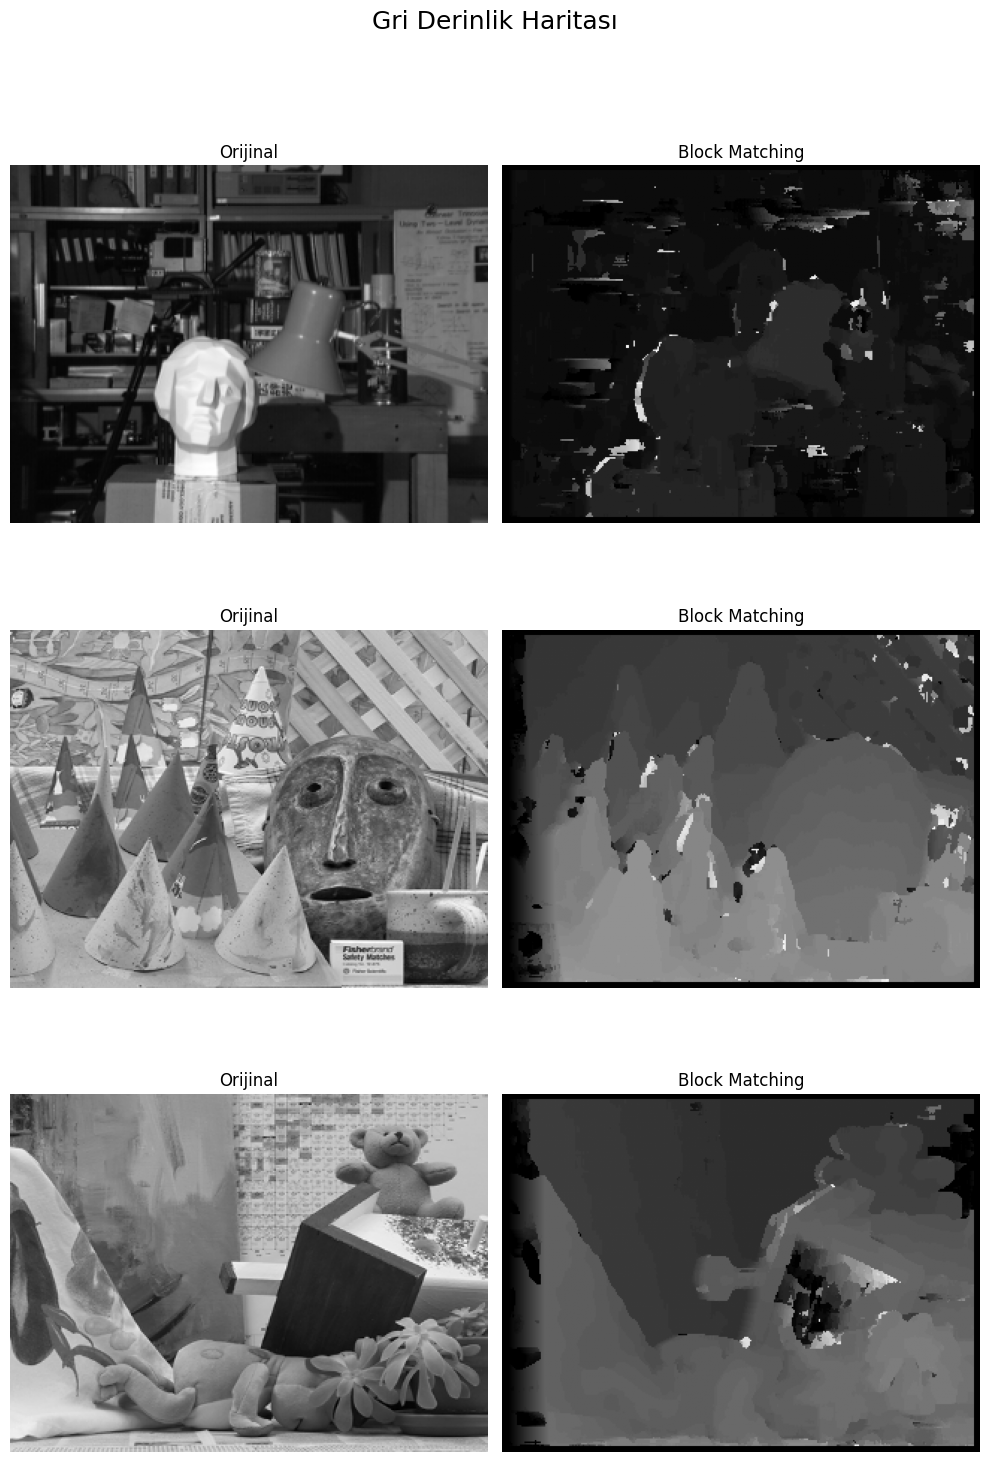

In [4]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

def manuel_block_matching(sol_img, sag_img, pencere_boyutu=5, maksimum_kayma=64):
    """
    SAD (Sum of Absolute Differences) kullanarak manuel Blok Eşleştirme algoritması.
    """
    sol_img = sol_img.astype(np.float32)
    sag_img = sag_img.astype(np.float32)
    
    h, w = sol_img.shape
    derinlik_haritasi = np.zeros((h, w), dtype=np.float32)
    
    yari_pencere = pencere_boyutu // 2
    
    baslangic_zaman = time.time()

    # Epipolar Geometri: Satır satır gez (y ekseni)
    for y in range(yari_pencere, h - yari_pencere):
        
        if y % 40 == 0:
            print(f"İlerleme: Satır {y}/{h} işleniyor...")
            
        for x in range(yari_pencere, w - yari_pencere):
         
            sol_blok = sol_img[y - yari_pencere : y + yari_pencere + 1, 
                               x - yari_pencere : x + yari_pencere + 1]
            
            en_iyi_kayma = 0
            minimum_hata = float('inf') 
            
            for d in range(0, maksimum_kayma):
                if x - d - yari_pencere < 0:
                    break 
                    
                sag_blok = sag_img[y - yari_pencere : y + yari_pencere + 1, 
                                   (x - d) - yari_pencere : (x - d) + yari_pencere + 1]
                
                sad_hata = np.sum(np.abs(sol_blok - sag_blok))
                
                if sad_hata < minimum_hata:
                    minimum_hata = sad_hata
                    en_iyi_kayma = d
                    
            derinlik_haritasi[y, x] = en_iyi_kayma
            
    gecen_sure = time.time() - baslangic_zaman
    print(f"Hesaplama tamamlandı! Süre: {gecen_sure:.2f} saniye.")
    
    return derinlik_haritasi

# GÖRSEL İŞLEME DÖNGÜSÜ
gorsel_ciftleri = [
    ('sol1.jpg', 'sag1.jpg'),
    ('sol2.png', 'sag2.png'),
    ('sol3.png', 'sag3.png')
]

maksimum_kayma = 64
pencere_boyutu = 9

fig, eksenler = plt.subplots(nrows=len(gorsel_ciftleri), ncols=2, figsize=(10, 5 * len(gorsel_ciftleri)))
fig.suptitle('Gri Derinlik Haritası', fontsize=18, y=1.02)

if len(gorsel_ciftleri) == 1:
    eksenler = np.expand_dims(eksenler, axis=0)

for i, (sol_dosya, sag_dosya) in enumerate(gorsel_ciftleri):
    print(f"\n--- {i+1}. Görsel çifti işleniyor ---")
    
    sol_img = cv2.imread(sol_dosya, 0)
    sag_img = cv2.imread(sag_dosya, 0)
    
    if sol_img is None or sag_img is None:
        print(f"Hata: {sol_dosya} veya {sag_dosya} bulunamadı!")
        continue
        
    sol_img = cv2.resize(sol_img, (320, 240))
    sag_img = cv2.resize(sag_img, (320, 240))
    
    # Block Matching
    disp_manuel_ham = manuel_block_matching(sol_img, sag_img, pencere_boyutu, maksimum_kayma)
    disp_manuel_gorsel = cv2.normalize(disp_manuel_ham, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # Sütun 1: Orijinal
    eksenler[i, 0].imshow(sol_img, cmap='gray')
    eksenler[i, 0].set_title('Orijinal')
    eksenler[i, 0].axis('off')

    # Sütun 2: Gri Derinlik Haritası
    eksenler[i, 1].imshow(disp_manuel_gorsel, cmap='gray')
    eksenler[i, 1].set_title('Block Matching')
    eksenler[i, 1].axis('off')

print("\nTüm çıktılar hazır! Ekrana yansıtılıyor...")
plt.tight_layout()
plt.show()

Hesaplama bitti! Süre: 8.27 saniye.

Hesaplama bitti! Süre: 8.69 saniye.

Hesaplama bitti! Süre: 8.40 saniye.

İşlemler tamamlandı! Ekrana yansıtılıyor...


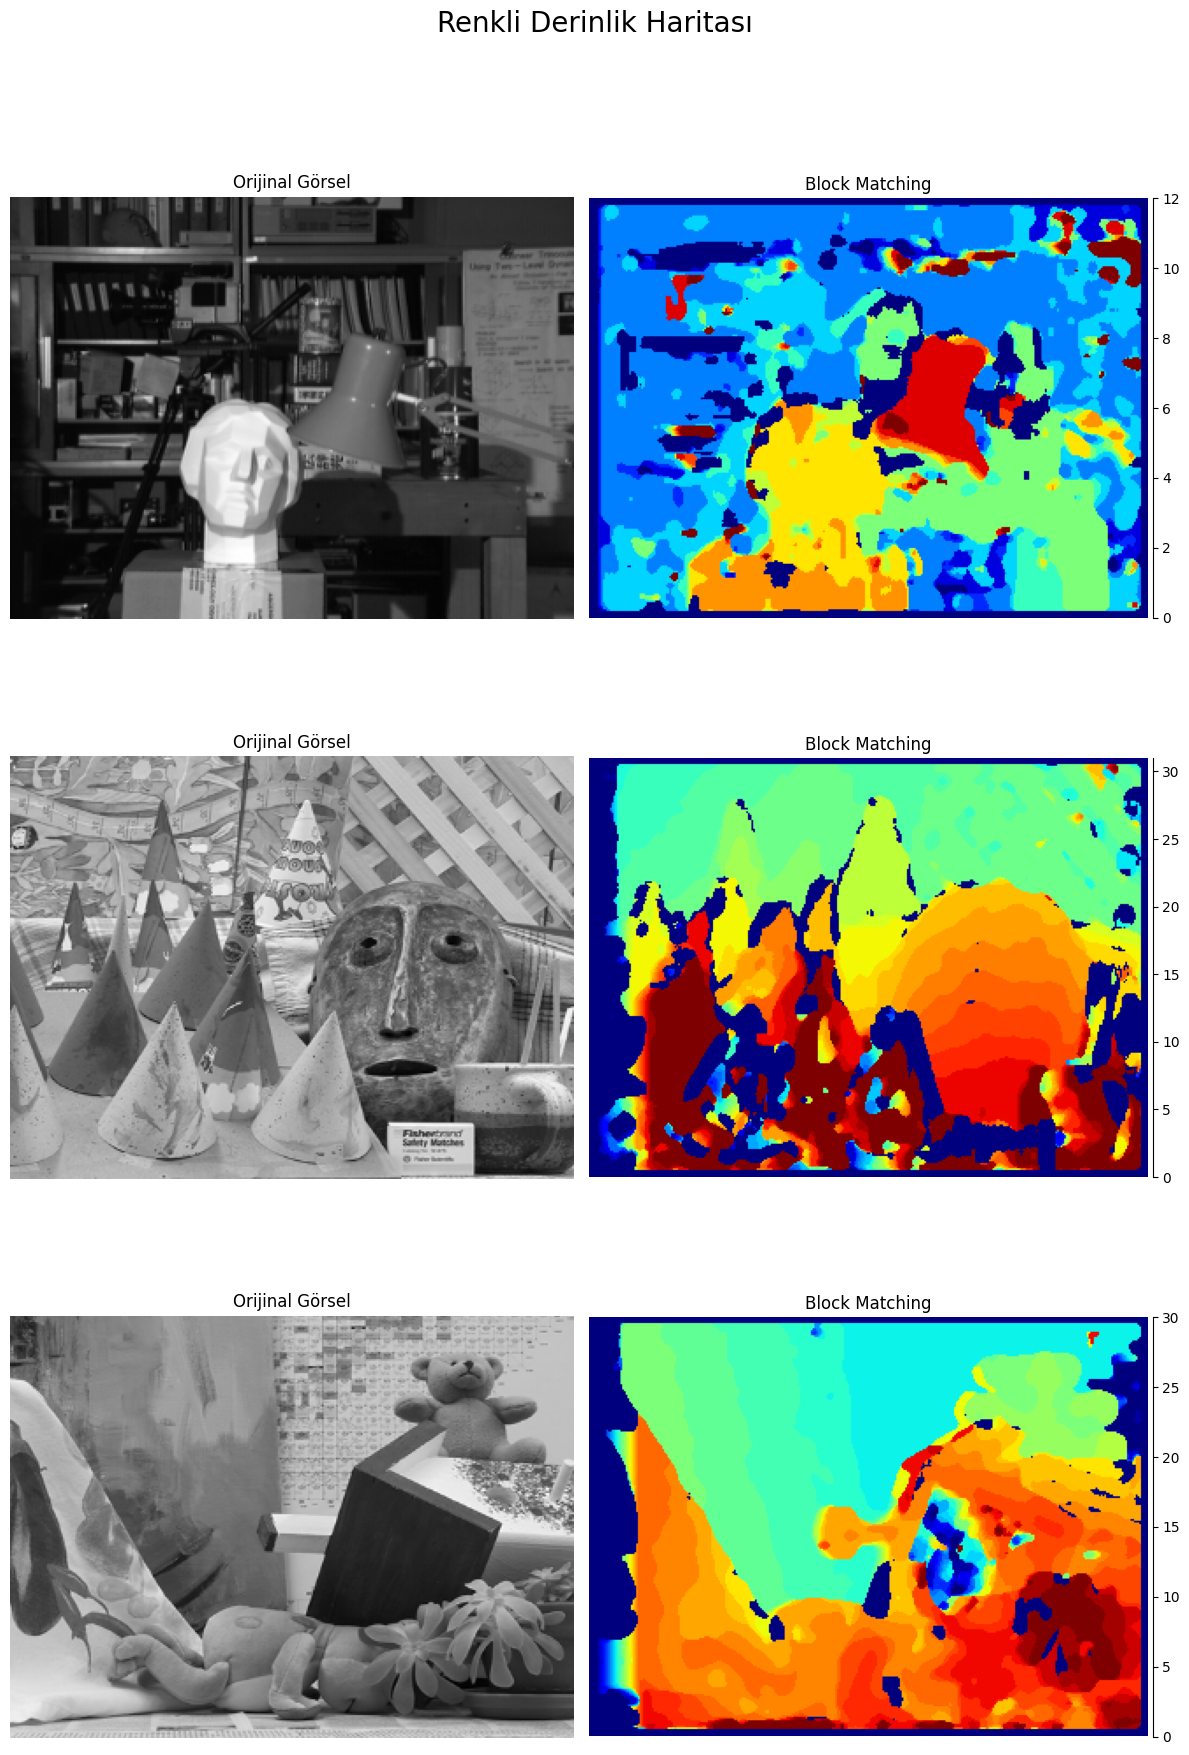

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from mpl_toolkits.axes_grid1 import make_axes_locatable 

def basite_indirgenmis_block_matching(sol_img, sag_img, pencere_boyutu=9, maksimum_kayma=32):
    """
    Güvenilirlik Maskesi (SAD maliyet eşiği) kullanarak basitleştirilmiş BM.
    Dokusuz bölgelerdeki gürültüyü siler.
    """
    sol_img = sol_img.astype(np.float32)
    sag_img = sag_img.astype(np.float32)
    
    h, w = sol_img.shape
    derinlik_haritasi = np.zeros((h, w), dtype=np.float32)
    
    maliyet_haritasi = np.full((h, w), float('inf'), dtype=np.float32)
    
    yari_pencere = pencere_boyutu // 2
    
    baslangic_zaman = time.time()

    for y in range(yari_pencere, h - yari_pencere):
        for x in range(yari_pencere, w - yari_pencere):
            sol_blok = sol_img[y - yari_pencere : y + yari_pencere + 1, 
                               x - yari_pencere : x + yari_pencere + 1]
            
            for d in range(0, maksimum_kayma):
                if x - d - yari_pencere < 0:
                    break 
                    
                sag_blok = sag_img[y - yari_pencere : y + yari_pencere + 1, 
                                   (x - d) - yari_pencere : (x - d) + yari_pencere + 1]
                
                sad_hata = np.sum(np.abs(sol_blok - sag_blok))
                
                if sad_hata < maliyet_haritasi[y, x]:
                    maliyet_haritasi[y, x] = sad_hata
                    derinlik_haritasi[y, x] = d
                    
    gecen_sure = time.time() - baslangic_zaman
    print(f"Hesaplama bitti! Süre: {gecen_sure:.2f} saniye.\n")
    
    return derinlik_haritasi, maliyet_haritasi

# --- GÖRSEL İŞLEME DÖNGÜSÜ ---
gorsel_ciftleri = [
    ('sol1.jpg', 'sag1.jpg'),
    ('sol2.png', 'sag2.png'),
    ('sol3.png', 'sag3.png')
]

pencere_boyutu = 9  
maksimum_kayma = 32  
maliyet_esigi = 1200 

fig, eksenler = plt.subplots(nrows=len(gorsel_ciftleri), ncols=2, figsize=(12, 6 * len(gorsel_ciftleri)))
fig.suptitle('Renkli Derinlik Haritası', fontsize=20, y=1.02)

if len(gorsel_ciftleri) == 1:
    eksenler = np.expand_dims(eksenler, axis=0)

for i, (sol_dosya, sag_dosya) in enumerate(gorsel_ciftleri):
    
    sol_img = cv2.imread(sol_dosya, 0)
    sag_img = cv2.imread(sag_dosya, 0)
    
    if sol_img is None or sag_img is None:
        print(f"Hata: Dosyalar okunamadı.\n")
        continue

    sol_img = cv2.resize(sol_img, (320, 240))
    sag_img = cv2.resize(sag_img, (320, 240))

    disp_ham, cost_ham = basite_indirgenmis_block_matching(sol_img, sag_img, pencere_boyutu, maksimum_kayma)
    disp_temiz = cv2.medianBlur(disp_ham.astype(np.uint8), 5)
    disp_temiz[cost_ham > maliyet_esigi] = 0

    tepe_deger = np.percentile(disp_temiz, 98)
    if tepe_deger == 0: 
        tepe_deger = maksimum_kayma

    # Sütun 1: Orijinal
    eksenler[i, 0].imshow(sol_img, cmap='gray')
    eksenler[i, 0].set_title('Orijinal Görsel')
    eksenler[i, 0].axis('off')

    # Sütun 2: Renkli Derinlik Haritası
    harita_simplified = eksenler[i, 1].imshow(disp_temiz, cmap='jet', vmin=0, vmax=tepe_deger)
    eksenler[i, 1].set_title('Block Matching')
    eksenler[i, 1].axis('off')

    divider = make_axes_locatable(eksenler[i, 1])
    cax = divider.append_axes("right", size="0%", pad=0.05)
    fig.colorbar(harita_simplified, cax=cax)

print("İşlemler tamamlandı! Ekrana yansıtılıyor...")
plt.tight_layout()
plt.show()

1. Görsel çifti işleniyor: sol1.jpg & sag1.jpg
2. Görsel çifti işleniyor: sol2.png & sag2.png
3. Görsel çifti işleniyor: sol3.png & sag3.png
Tüm işlemler başarıyla tamamlandı! Haritalar çiziliyor...


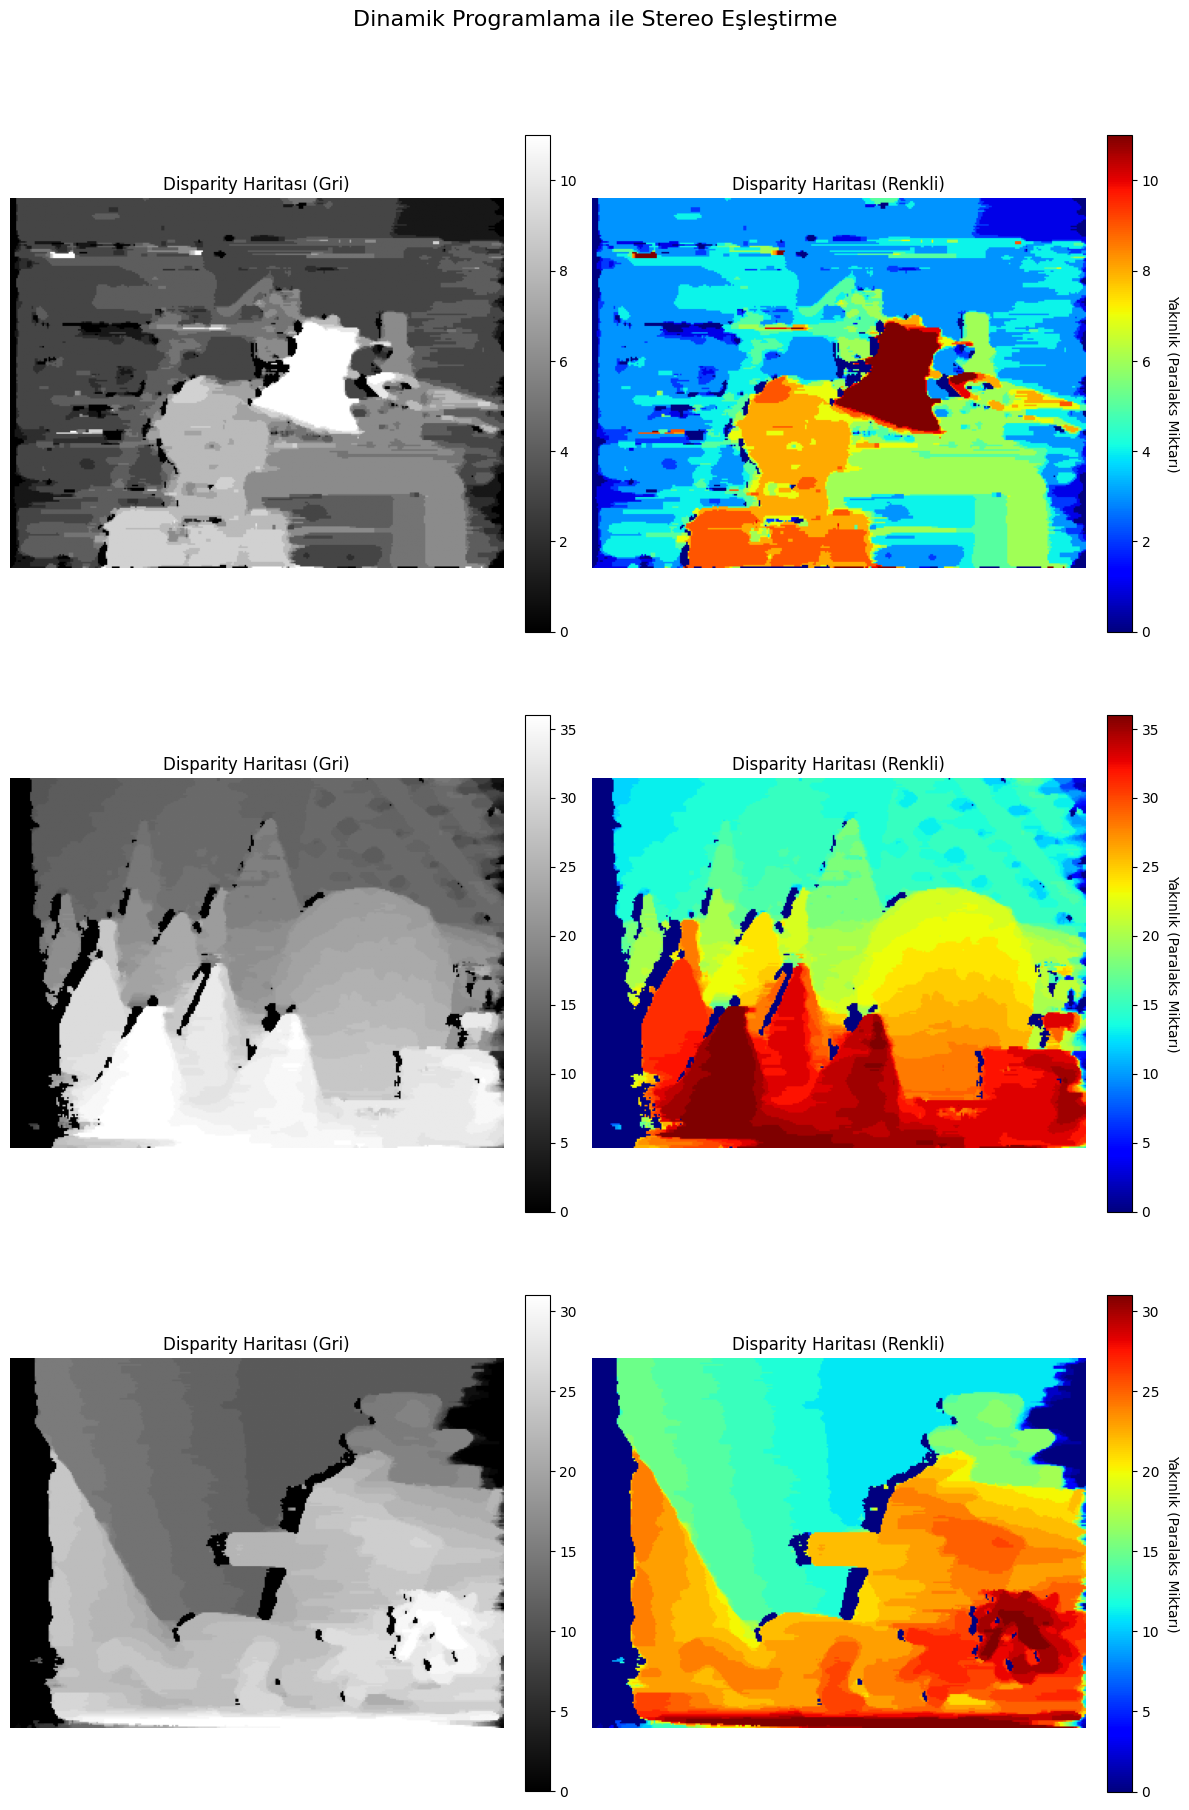

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def dinamikProgramlamaEsleme(sol_img, sag_img, satirlar, sutunlar):

    sol_img = sol_img.astype(np.int32)
    sag_img = sag_img.astype(np.int32)
    
    paralaks_haritasi = np.zeros((satirlar, sutunlar), dtype=np.uint8)
    ortusme_esigi = 10
    
    for satir in range(satirlar):
        maliyet_matrisi = np.zeros((sutunlar, sutunlar))
        yol_izleyici = np.zeros((sutunlar, sutunlar), dtype=np.int8) 
        
        for i in range(sutunlar):
            maliyet_matrisi[i, 0] = i * ortusme_esigi
            maliyet_matrisi[0, i] = i * ortusme_esigi
            yol_izleyici[i, 0] = 1
            yol_izleyici[0, i] = 2
            
        for i in range(1, sutunlar):
            for j in range(1, sutunlar):
                anlik_maliyet = abs(sol_img[satir, i] - sag_img[satir, j])
                
                secenek_eslesme = maliyet_matrisi[i-1, j-1] + anlik_maliyet
                secenek_sol = maliyet_matrisi[i-1, j] + ortusme_esigi
                secenek_sag = maliyet_matrisi[i, j-1] + ortusme_esigi
                
                min_maliyet = min(secenek_eslesme, secenek_sol, secenek_sag)
                maliyet_matrisi[i, j] = min_maliyet
                
                if min_maliyet == secenek_eslesme:
                    yol_izleyici[i, j] = 0
                elif min_maliyet == secenek_sol:
                    yol_izleyici[i, j] = 1
                else:
                    yol_izleyici[i, j] = 2
                    
        i = sutunlar - 1
        j = sutunlar - 1
        
        while i > 0 and j > 0:
            if yol_izleyici[i, j] == 0:
                paralaks_haritasi[satir, i] = abs(i - j)
                i -= 1
                j -= 1
            elif yol_izleyici[i, j] == 1:
                i -= 1 
            else:
                j -= 1 
                
    return paralaks_haritasi


def derinlikHaritasiGetir(satirlar, sutunlar, paralaks_haritasi, baseline, f_x):
    derinlik_haritasi = np.zeros((satirlar, sutunlar))
    
    for i in range(satirlar):
        for j in range(sutunlar):
            if paralaks_haritasi[i, j] > 0: 
                derinlik_haritasi[i, j] = (baseline * f_x) / paralaks_haritasi[i, j]
            else:
                derinlik_haritasi[i, j] = 0 
                
    return derinlik_haritasi

gorsel_ciftleri = [
    ('sol1.jpg', 'sag1.jpg'),
    ('sol2.png', 'sag2.png'),
    ('sol3.png', 'sag3.png')
]

B = 6.0 
f_x = 800 

fig, eksenler = plt.subplots(nrows=len(gorsel_ciftleri), ncols=2, figsize=(12, 6 * len(gorsel_ciftleri)))
fig.suptitle('Dinamik Programlama ile Stereo Eşleştirme', fontsize=16, y=1.02)

for i, (sol_dosya, sag_dosya) in enumerate(gorsel_ciftleri):
    print(f"{i+1}. Görsel çifti işleniyor: {sol_dosya} & {sag_dosya}")
    
    # Görüntüleri siyah beyaz okuma
    sol_img = cv2.imread(sol_dosya, 0)
    sag_img = cv2.imread(sag_dosya, 0)
    
    if sol_img is None or sag_img is None:
        print(f"Hata: {sol_dosya} veya {sag_dosya} okunamadı. Atlanıyor...")
        continue
        
    sol_img = cv2.resize(sol_img, (320, 240))
    sag_img = cv2.resize(sag_img, (320, 240))
    satirlar, sutunlar = sol_img.shape
    
    # 1. Paralaks Haritasını Çıkar
    dp_paralaks_ham = dinamikProgramlamaEsleme(sol_img, sag_img, satirlar, sutunlar)
    
    dp_paralaks_ham[dp_paralaks_ham > 100] = 0 
    dp_paralaks_temiz = cv2.medianBlur(dp_paralaks_ham, 5)
    
    ust_sinir_dp = np.percentile(dp_paralaks_temiz, 98)
    
    # Sol Görsel (Siyah Beyaz Paralaks Çıktısı)
    harita_sb = eksenler[i, 0].imshow(dp_paralaks_temiz, cmap='gray', vmax=ust_sinir_dp)
    eksenler[i, 0].set_title(f'Disparity Haritası (Gri)')
    eksenler[i, 0].axis('off') 
    fig.colorbar(harita_sb, ax=eksenler[i, 0], fraction=0.046, pad=0.04)g
    
    # Sağ Görsel (Renkli Paralaks Çıktısı)
    harita_renkli = eksenler[i, 1].imshow(dp_paralaks_temiz, cmap='jet', vmax=ust_sinir_dp)
    eksenler[i, 1].set_title(f'Disparity Haritası (Renkli)')
    eksenler[i, 1].axis('off')
    cbar = fig.colorbar(harita_renkli, ax=eksenler[i, 1], fraction=0.046, pad=0.04)
    cbar.set_label('Yakınlık (Paralaks Miktarı)', rotation=270, labelpad=15)

print("Tüm işlemler başarıyla tamamlandı! Haritalar çiziliyor...")
plt.tight_layout()
plt.show()